In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("atm_data.csv")
df.head()

,id,atm_name,weekday,festival_religion,working_day,holiday_sequence,trans_date_set,trans_month,trans_year,prevweek_mean,total_amount_withdrawn
0,11,Mount Road ATM,MONDAY,NH,W,WWW,1,1,2011,648600,897100
1,16,Mount Road ATM,TUESDAY,NH,W,WWW,1,1,2011,648600,826000
2,21,Mount Road ATM,WEDNESDAY,NH,W,WWW,1,1,2011,648600,754400
3,26,Mount Road ATM,THURSDAY,NH,W,WWW,2,1,2011,648600,834200
4,31,Mount Road ATM,FRIDAY,NH,W,WWW,2,1,2011,648600,575300


In [3]:
df["date"] = pd.to_datetime(
    df["trans_year"].astype(str) + "-" +
    df["trans_month"].astype(str) + "-" +
    df["trans_date_set"].astype(str)
)

df[["date", "total_amount_withdrawn"]].head()

,date,total_amount_withdrawn
0,2011-01-01,897100
1,2011-01-01,826000
2,2011-01-01,754400
3,2011-01-02,834200
4,2011-01-02,575300


In [4]:
data = df.groupby("date")["total_amount_withdrawn"].sum().reset_index()

data.head(10)

,date,total_amount_withdrawn
0,2011-01-01,2477500
1,2011-01-02,3656200
2,2011-01-03,2311800
3,2011-01-04,1935600
4,2011-01-05,2196300
5,2011-01-06,1777600
6,2011-01-07,515100
7,2011-02-01,3562500
8,2011-02-02,2900500
9,2011-02-03,2092000


In [5]:
df["date"] = pd.to_datetime(
    df["trans_date_set"].astype(str) + "-" +
    df["trans_month"].astype(str) + "-" +
    df["trans_year"].astype(str),
    dayfirst=True
)

df[["date", "total_amount_withdrawn"]].head()

,date,total_amount_withdrawn
0,2011-01-01,897100
1,2011-01-01,826000
2,2011-01-01,754400
3,2011-01-02,834200
4,2011-01-02,575300


In [6]:
data = df.groupby("date")["total_amount_withdrawn"].sum().reset_index()

data.head(10)

,date,total_amount_withdrawn
0,2011-01-01,2477500
1,2011-01-02,3656200
2,2011-01-03,2311800
3,2011-01-04,1935600
4,2011-01-05,2196300
5,2011-01-06,1777600
6,2011-01-07,515100
7,2011-02-01,3562500
8,2011-02-02,2900500
9,2011-02-03,2092000


In [7]:
df[["trans_date_set", "trans_month", "trans_year"]].drop_duplicates().head(30)

,trans_date_set,trans_month,trans_year
0,1,1,2011
3,2,1,2011
8,3,1,2011
13,4,1,2011
18,5,1,2011
23,6,1,2011
28,7,1,2011
29,1,2,2011
34,2,2,2011
39,3,2,2011


In [8]:
df["date"] = pd.to_datetime(
    df["trans_year"].astype(str) + "-" +
    df["trans_month"].astype(str) + "-" +
    df["trans_date_set"].astype(str)
)

data = df.groupby("date")["total_amount_withdrawn"].sum().reset_index()

data.set_index("date", inplace=True)

data.head(15)

,total_amount_withdrawn
date,
2011-01-01,2477500
2011-01-02,3656200
2011-01-03,2311800
2011-01-04,1935600
2011-01-05,2196300
2011-01-06,1777600
2011-01-07,515100
2011-02-01,3562500
2011-02-02,2900500


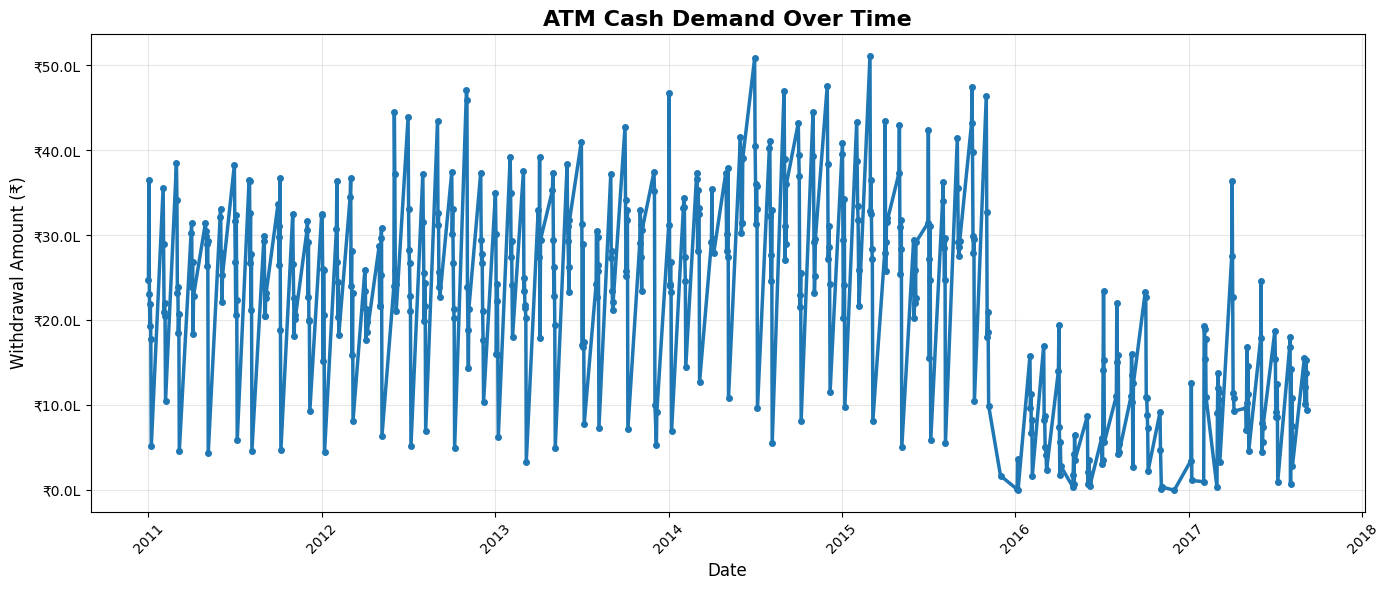

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(14,6))

plt.plot(
    data.index,
    data["total_amount_withdrawn"],
    linewidth=2.5,
    marker="o",
    markersize=4
)

plt.title("ATM Cash Demand Over Time", fontsize=16, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Withdrawal Amount (₹)", fontsize=12)

plt.grid(alpha=0.3)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'₹{x/100000:.1f}L')
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [10]:
series = data["total_amount_withdrawn"]

train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

print("Train size:", len(train))
print("Test size :", len(test))
print("Total rows :", len(series))

Train size: 407
Test size : 102
Total rows : 509


In [11]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(5,0,5))
model_fit = model.fit()

print(model_fit.summary())

C:\Users\bisht\.conda\envs\main\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\bisht\.conda\envs\main\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\bisht\.conda\envs\main\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                 SARIMAX Results                                  
Dep. Variable:     total_amount_withdrawn   No. Observations:                  407
Model:                     ARIMA(5, 0, 5)   Log Likelihood               -6155.225
Date:                    Sun, 12 Apr 2026   AIC                          12334.450
Time:                            19:41:47   BIC                          12382.556
Sample:                                 0   HQIC                         12353.488
                                    - 407                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.597e+06   2.31e-09   1.13e+15      0.000     2.6e+06     2.6e+06
ar.L1          0.5520      0.047     11.679      0.000       0.459       0.645
ar.L2          0.284

C:\Users\bisht\.conda\envs\main\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [12]:
pred = model_fit.forecast(steps=len(test))

print(pred.head())
print("Predictions:", len(pred))

407    1.078558e+06
408    9.148703e+05
409    8.289217e+05
410    1.148083e+06
411    1.206210e+06
Name: predicted_mean, dtype: float64
Predictions: 102


C:\Users\bisht\.conda\envs\main\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\bisht\.conda\envs\main\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))

MAE : 820577.3
RMSE: 955057.44


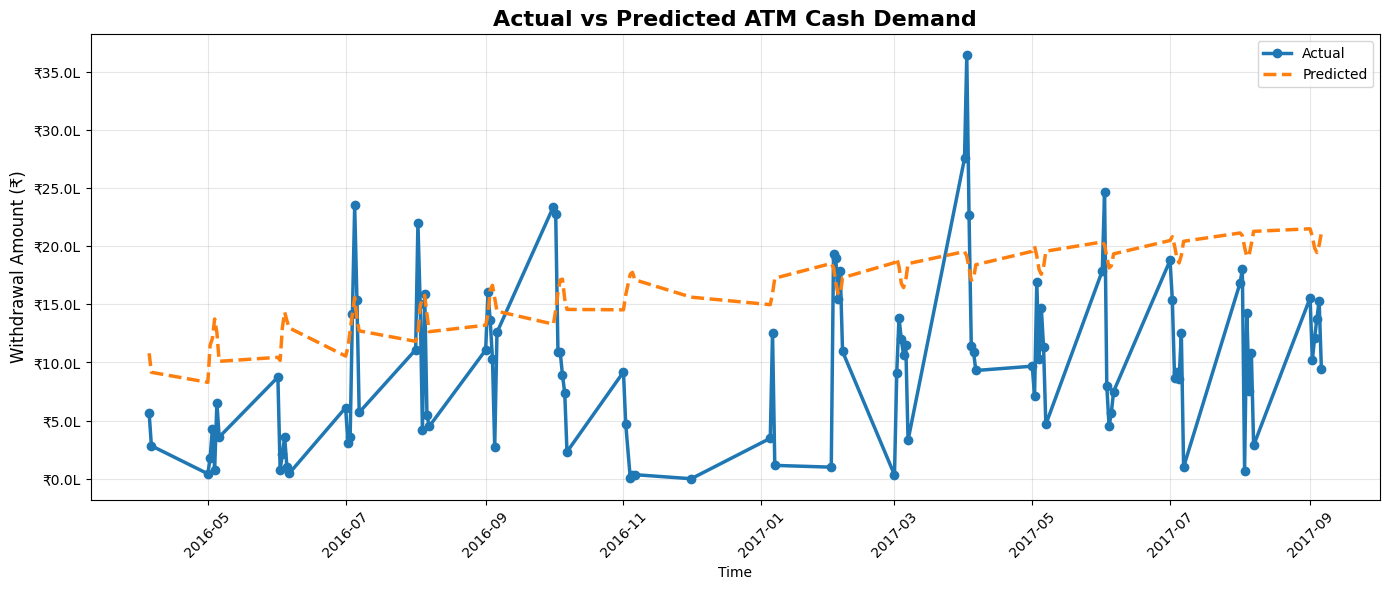

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(14,6))

# Lines
plt.plot(test.index, test.values, label="Actual", linewidth=2.5, marker="o")
plt.plot(test.index, pred.values, label="Predicted", linewidth=2.5, linestyle="--")

# Title and labels
plt.title("Actual vs Predicted ATM Cash Demand", fontsize=16, fontweight="bold")
plt.xlabel("Time")
plt.ylabel("Withdrawal Amount (₹)", fontsize=12)

# Grid
plt.grid(alpha=0.3)

# Currency format
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'₹{x/100000:.1f}L')
)

# X labels
plt.xticks(rotation=45)

# Legend
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
future = model_fit.forecast(steps=7)

print("Next 7 Forecast Values:")
print(future)

Next 7 Forecast Values:
407    1.078558e+06
408    9.148703e+05
409    8.289217e+05
410    1.148083e+06
411    1.206210e+06
412    1.373382e+06
413    1.256281e+06
Name: predicted_mean, dtype: float64


C:\Users\bisht\.conda\envs\main\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\bisht\.conda\envs\main\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [17]:
import joblib

# Save trained ARIMA model
joblib.dump(model_fit, "atm_cash_forecast_model.pkl")

print("Model saved successfully as atm_cash_forecast_model.pkl")

Model saved successfully as atm_cash_forecast_model.pkl
